<a href="https://colab.research.google.com/github/justamy20/Practical-Statistics-for-Data-Scientists/blob/main/Chapter3_Statistical_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Statistical Experiments and Significance Testing

## Objective
Memahami:
- A/B Testing
- Hypothesis Testing
- p-value
- Type I & Type II Error
- Permutation Test

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## A/B Testing

A/B testing digunakan untuk membandingkan dua kondisi:

- Group A = kontrol
- Group B = treatment

Tujuan:
Mengetahui apakah perbedaan yang terjadi signifikan atau hanya kebetulan

In [50]:
# simulasi data A/B testing
np.random.seed(42)

group_A = np.random.normal(50, 10, 100)
group_B = np.random.normal(55, 10, 100)

print("Mean A:", np.mean(group_A))
print("Mean B:", np.mean(group_B))

Mean A: 48.96153482605907
Mean B: 55.223045870499234


## Hypothesis Testing

- H0 (Null Hypothesis): tidak ada perbedaan
- H1 (Alternative Hypothesis): ada perbedaan

Contoh:
H0: Mean A = Mean B  
H1: Mean A ≠ Mean B

## Test Statistic

Untuk membandingkan dua mean:

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{SE}
$$

Dimana SE adalah standard error

In [52]:
mean_diff = np.mean(group_B) - np.mean(group_A)
print("Difference in Mean:", mean_diff)

Difference in Mean: 6.261511044440162


## p-value

p-value adalah probabilitas mendapatkan hasil setidaknya se-ekstrem ini
jika H0 benar.

- p-value kecil → tolak H0
- p-value besar → gagal tolak H0

Biasanya:
- p < 0.05 → signifikan

In [53]:
# permutation test
combined = np.concatenate([group_A, group_B])
observed_diff = np.mean(group_B) - np.mean(group_A)

perm_diffs = []

for _ in range(1000):
    np.random.shuffle(combined)
    new_A = combined[:100]
    new_B = combined[100:]
    perm_diffs.append(np.mean(new_B) - np.mean(new_A))

p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print("Observed Difference:", observed_diff)
print("p-value:", p_value)

Observed Difference: 6.261511044440162
p-value: 0.0


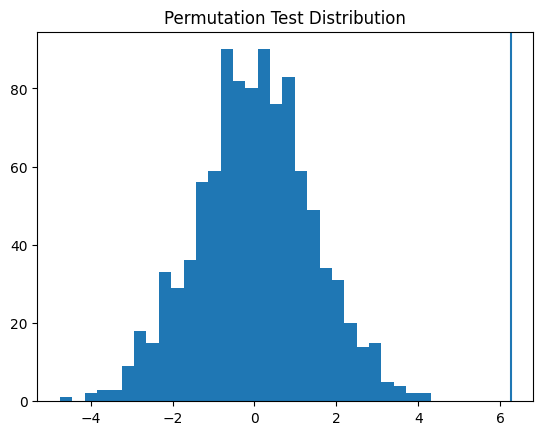

In [54]:
plt.hist(perm_diffs, bins=30)
plt.axvline(observed_diff)
plt.title("Permutation Test Distribution")
plt.show()

## Type I & Type II Error

- Type I Error:
  Menolak H0 padahal benar (False Positive)

- Type II Error:
  Gagal menolak H0 padahal salah (False Negative)

## Confidence Interval

Confidence interval memberikan range estimasi:

$$
CI = \bar{x} \pm Z \cdot SE
$$

Biasanya digunakan 95% confidence level

In [55]:
mean = np.mean(group_A)
std = np.std(group_A)
n = len(group_A)

SE = std / np.sqrt(n)

CI_lower = mean - 1.96 * SE
CI_upper = mean + 1.96 * SE

print("Confidence Interval:", (CI_lower, CI_upper))

Confidence Interval: (np.float64(47.190447119835596), np.float64(50.73262253228255))


## Insight

- A/B testing digunakan untuk membandingkan dua kelompok
- Hypothesis testing membantu mengambil keputusan berbasis data
- p-value menunjukkan signifikansi hasil
- Permutation test adalah metode non-parametrik
- Type I & II error penting dalam interpretasi hasil